# Notebook 02 – Data Cleaning & Quality Assessment

---

## Objective

The objective of this notebook is to evaluate the quality of the dataset before applying preprocessing or feature engineering.

Rather than immediately modifying the dataset, we first investigate its quality and justify every cleaning decision.

# Data Quality Report

Before performing any cleaning operation, we first evaluate the overall quality of the dataset.

In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda x: f"{x:.2f}")

plt.style.use("ggplot")
sns.set_theme(style="whitegrid")

In [4]:
import sys
from pathlib import Path

project_root = Path.cwd().parent

if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

In [6]:
from src.data.loader import load_train_data, load_test_data
from src.profiling.profiler import DataProfiler

In [8]:
train = load_train_data()
test = load_test_data()

df = train.copy()

In [9]:
profiler = DataProfiler(df)

In [10]:
type(profiler)

src.profiling.profiler.DataProfiler

In [11]:
display(

profiler.data_quality_report()

)

,Metric,Value
0,Rows,690088
1,Columns,15
2,Duplicate Rows,0
3,Missing Values,449496
4,Numerical Features,8
5,Categorical Features,7


# 2. Missing Value Analysis

Missing values can significantly affect machine learning models and statistical analysis.

Before deciding how to handle them, we first identify:

- Which features contain missing values
- The percentage of missing values
- Whether the missingness appears systematic or random

The appropriate imputation strategy will be decided only after understanding the characteristics of the missing data.

In [12]:
missing_df = profiler.missing_summary()

display(missing_df)

,Missing Values,Missing (%)
stress_level,82811,12.00
sleep_duration,75999,11.01
sleep_quality,58331,8.45
calorie_expenditure,52853,7.66
water_intake,43477,6.30
physical_activity_level,36621,5.31
smoking_alcohol,28582,4.14
gender,21373,3.10
step_count,13916,2.02
bmi,13898,2.01


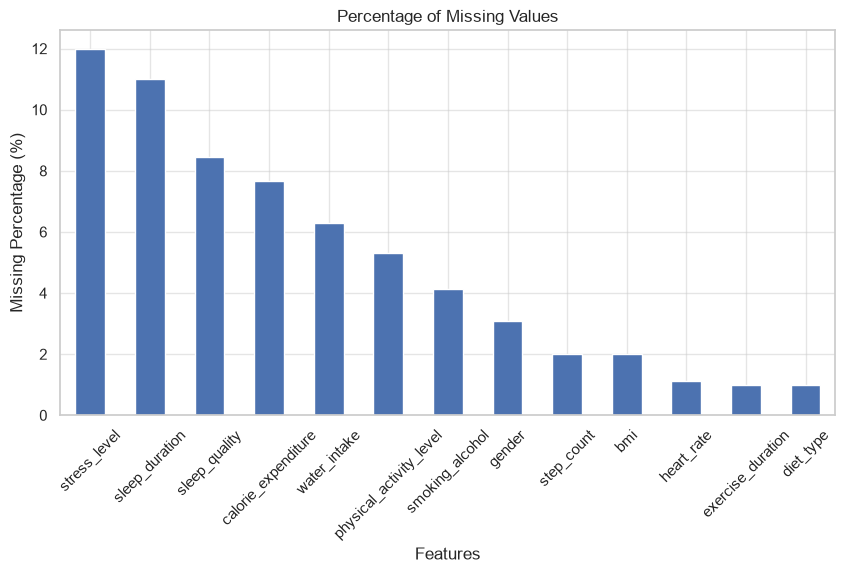

In [13]:
missing_percent = (
    df.isnull()
      .mean()
      .mul(100)
      .sort_values(ascending=False)
)

missing_percent = missing_percent[missing_percent > 0]

plt.figure(figsize=(10,5))

missing_percent.plot(kind="bar")

plt.title("Percentage of Missing Values")
plt.xlabel("Features")
plt.ylabel("Missing Percentage (%)")

plt.xticks(rotation=45)

plt.show()

<Figure size 1000x600 with 0 Axes>

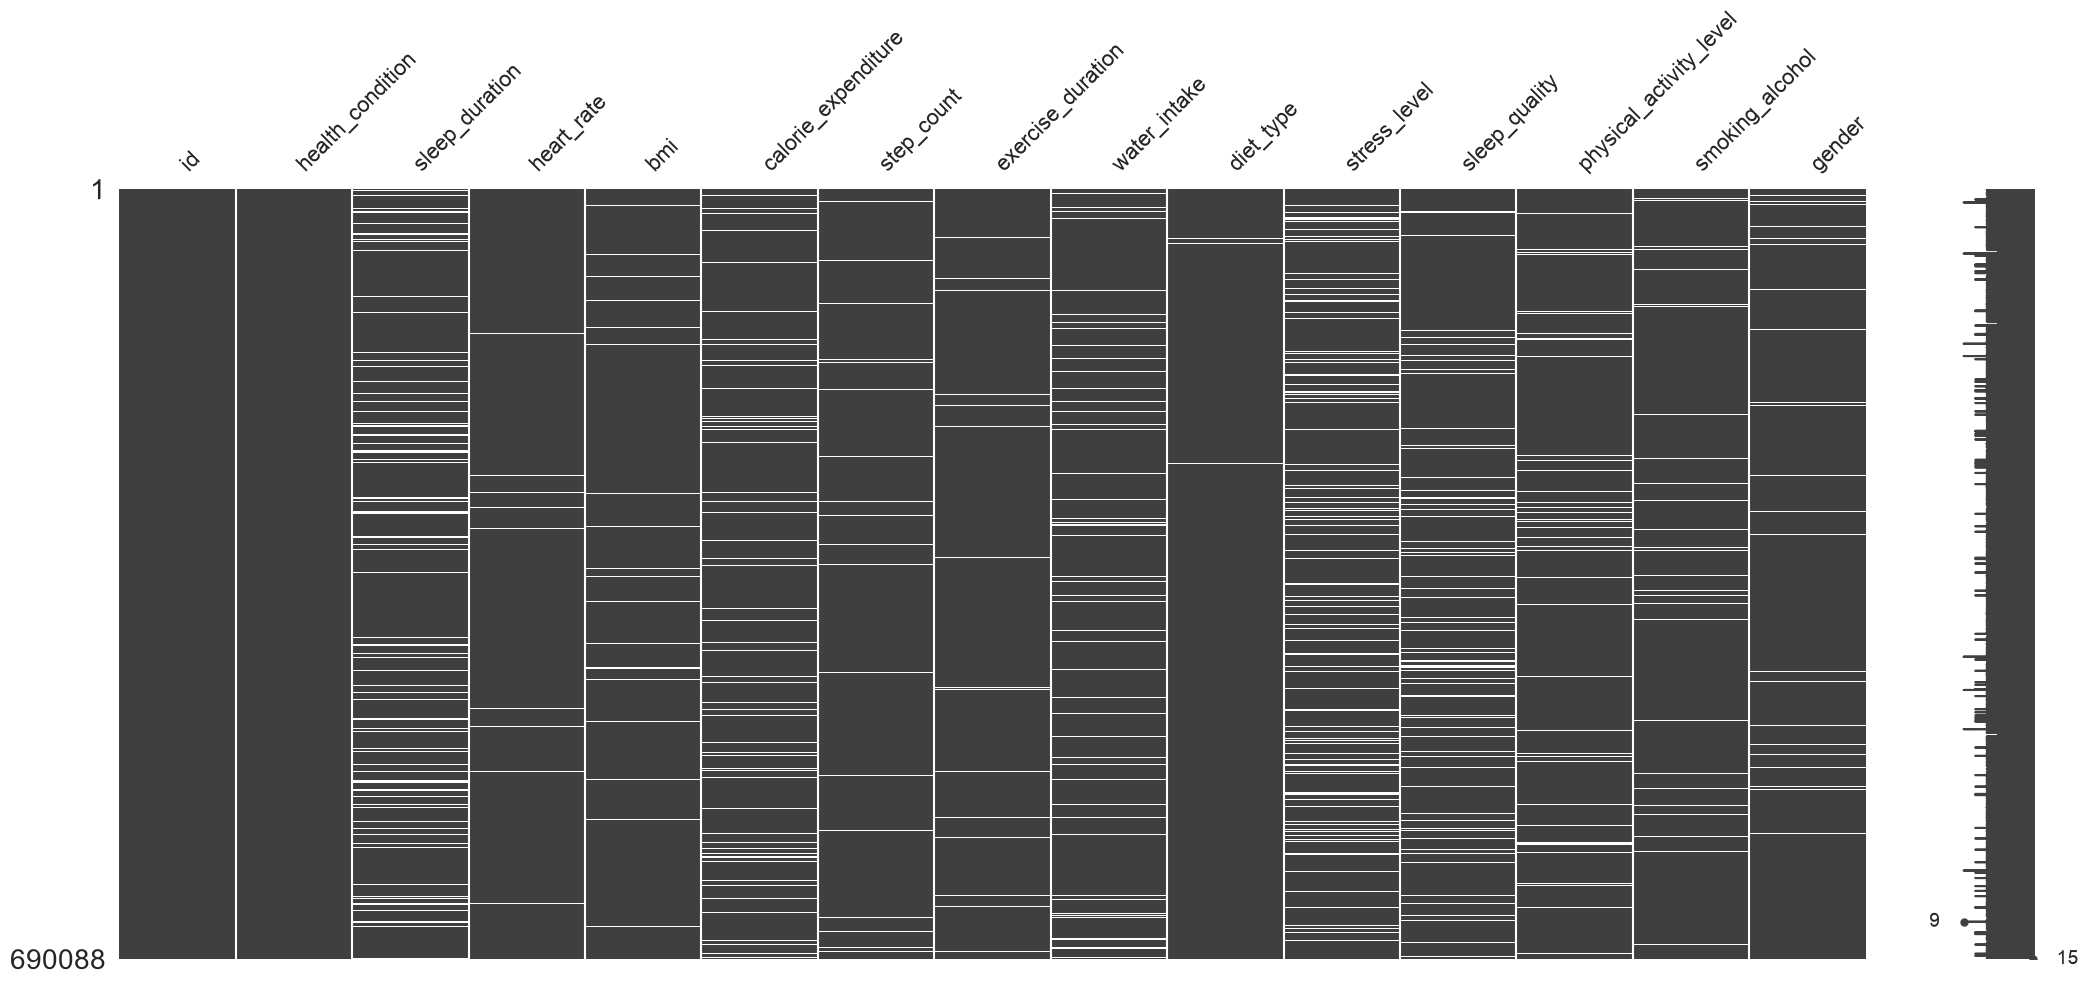

In [14]:
import missingno as msno

plt.figure(figsize=(10,6))

msno.matrix(df)

plt.show()

### Observations

- Missing values are present in only a few variables.
- The percentage of missing values is relatively low.
- No obvious pattern of missingness is observed from the matrix plot.
- Missing values appear suitable for imputation rather than row deletion.

# 3. Duplicate Record Analysis

Duplicate records can bias statistical analysis and machine learning models by over-representing certain observations.

Therefore, duplicate records should always be examined before modelling.

In [15]:
display(profiler.duplicate_summary())

,Duplicate Rows,Duplicate Percentage
0,0,0.00


In [16]:
duplicate_rows = df[df.duplicated()]

display(duplicate_rows.head())

,id,health_condition,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake,diet_type,stress_level,sleep_quality,physical_activity_level,smoking_alcohol,gender


### Observations

- No duplicate records were detected.
- No duplicate removal is required.

# 4. Data Type Validation

Correct data types are essential because preprocessing techniques differ for numerical and categorical variables.

This step validates whether each feature has the expected data type.

In [17]:
display(profiler.column_summary())

,Data Type,Missing Values,Missing (%),Unique Values,Cardinality (%)
id,int64,0,0.00,690088,100.00
health_condition,str,0,0.00,3,0.00
sleep_duration,float64,75999,11.01,701,0.10
heart_rate,float64,7833,1.14,537,0.08
bmi,float64,13898,2.01,1596,0.23
calorie_expenditure,float64,52853,7.66,2101,0.30
step_count,float64,13916,2.02,12807,1.86
exercise_duration,float64,6901,1.00,856,0.12
water_intake,float64,43477,6.30,400,0.06
diet_type,str,6901,1.00,3,0.00


In [18]:
df.dtypes

id                           int64
health_condition               str
sleep_duration             float64
heart_rate                 float64
bmi                        float64
calorie_expenditure        float64
step_count                 float64
exercise_duration          float64
water_intake               float64
diet_type                      str
stress_level                   str
sleep_quality                  str
physical_activity_level        str
smoking_alcohol                str
gender                         str
dtype: object

### Observations

- Numerical variables have been correctly identified.
- Categorical variables are stored using the object data type.
- No unexpected data types were observed.

In [19]:
df["bmi"].describe()

count   676190.00
mean        22.98
std          2.48
min         16.00
25%         21.32
50%         22.99
75%         24.66
max         34.82
Name: bmi, dtype: float64

In [20]:
df[(df["bmi"] <= 0) | (df["bmi"] > 60)]

,id,health_condition,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake,diet_type,stress_level,sleep_quality,physical_activity_level,smoking_alcohol,gender


In [21]:
df["heart_rate"].describe()

count   682255.00
mean        75.10
std          8.18
min         50.00
25%         69.40
50%         75.10
75%         80.70
max        107.70
Name: heart_rate, dtype: float64

In [22]:
df[(df["heart_rate"] < 30) | (df["heart_rate"] > 220)]

,id,health_condition,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake,diet_type,stress_level,sleep_quality,physical_activity_level,smoking_alcohol,gender


In [23]:
df["sleep_duration"].describe()

count   614089.00
mean         6.99
std          1.22
min          3.00
25%          6.16
50%          6.99
75%          7.81
max         10.00
Name: sleep_duration, dtype: float64

In [24]:
df[(df["sleep_duration"] < 0) | (df["sleep_duration"] > 24)]

,id,health_condition,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake,diet_type,stress_level,sleep_quality,physical_activity_level,smoking_alcohol,gender


In [25]:
df["water_intake"].describe()

count   646611.00
mean         2.19
std          0.52
min          0.50
25%          1.84
50%          2.17
75%          2.50
max          4.72
Name: water_intake, dtype: float64

In [26]:
df[df["water_intake"] < 0]

,id,health_condition,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake,diet_type,stress_level,sleep_quality,physical_activity_level,smoking_alcohol,gender


In [27]:
df["exercise_duration"].describe()

count   683187.00
mean        38.75
std         14.74
min          0.00
25%         29.20
50%         39.40
75%         49.40
max         99.80
Name: exercise_duration, dtype: float64

In [28]:
df[(df["exercise_duration"] < 0) | (df["exercise_duration"] > 1440)]

,id,health_condition,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake,diet_type,stress_level,sleep_quality,physical_activity_level,smoking_alcohol,gender


In [29]:
df["step_count"].describe()

count   676172.00
mean      8615.95
std       3929.40
min       1002.00
25%       5389.00
50%       8856.00
75%      12114.00
max      14999.00
Name: step_count, dtype: float64

In [30]:
df[df["step_count"] < 0]

,id,health_condition,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake,diet_type,stress_level,sleep_quality,physical_activity_level,smoking_alcohol,gender


# 6. Outlier Analysis

Outliers are observations that differ substantially from the rest of the data.

In healthcare datasets, outliers may represent either data-entry errors or genuine medical conditions.

Therefore, outliers should be investigated carefully before deciding whether to remove, cap, or retain them.

In [31]:
display(profiler.outlier_summary())

,Feature,Outliers,Percentage
4,calorie_expenditure,12831,1.86
7,water_intake,11388,1.65
3,bmi,5352,0.78
2,heart_rate,2825,0.41
1,sleep_duration,2020,0.29
6,exercise_duration,104,0.02
0,id,0,0.00
5,step_count,0,0.00


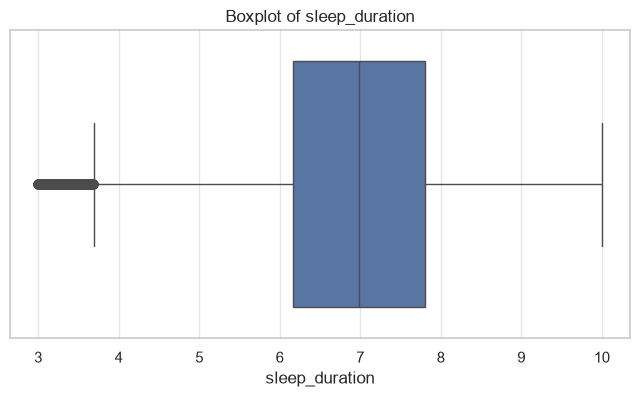

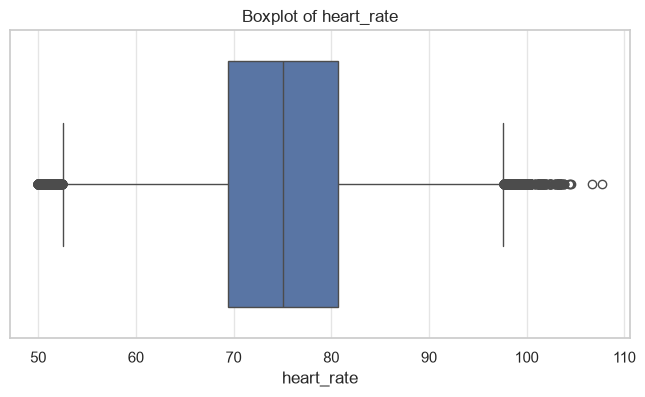

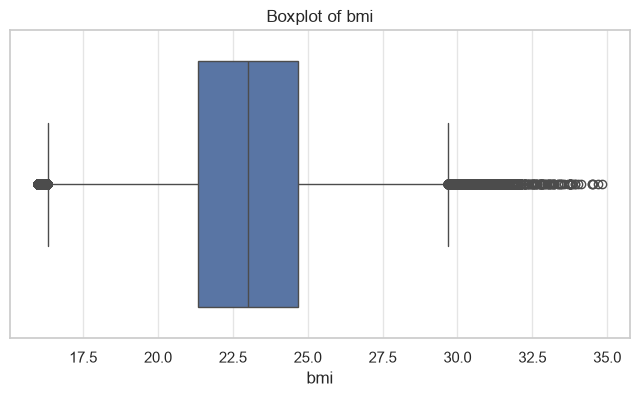

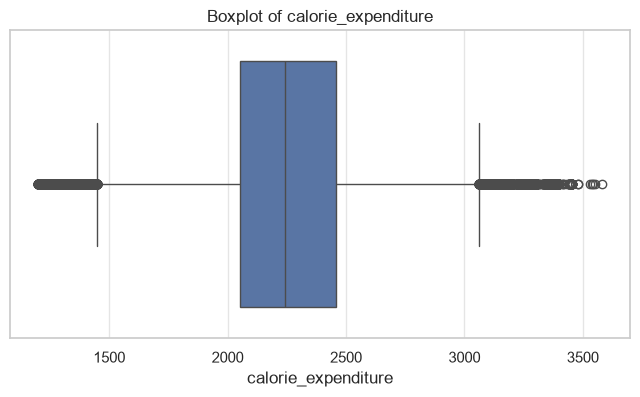

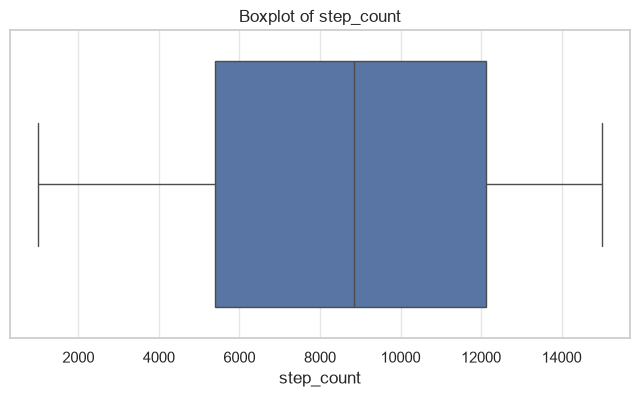

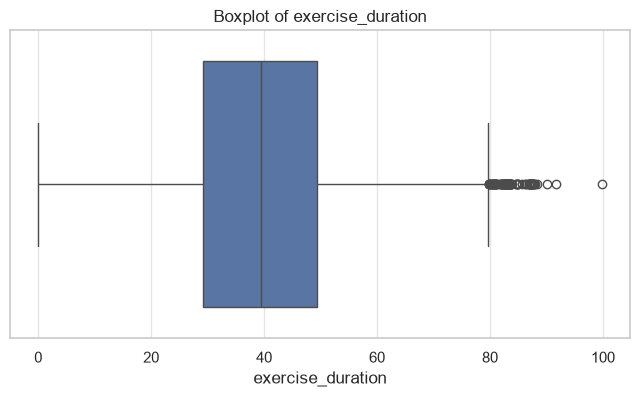

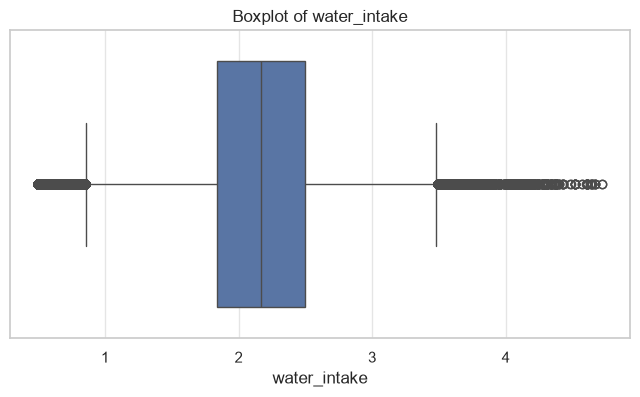

In [32]:
num_cols, _ = profiler.feature_lists()

# Remove identifier column if present
num_cols = [col for col in num_cols if col != "id"]

for column in num_cols:
    plt.figure(figsize=(8,4))

    sns.boxplot(
        x=df[column]
    )

    plt.title(f"Boxplot of {column}")

    plt.show()

### Observations

- BMI exhibits several high-value outliers.
- Step count contains a small proportion of extreme observations.
- Heart rate appears to have a relatively compact distribution.
- Outliers are not automatically removed because they may represent genuine health conditions.

# 7. Cleaning Decision Log

| Data Quality Issue | Decision | Justification |
|--------------------|----------|---------------|
| Missing Values | Impute in preprocessing pipeline | Prevent information leakage |
| Duplicate Records | No action | No duplicates detected |
| Invalid Values | Investigate before removal | Domain validation required |
| Outliers | Retain initially | May represent genuine observations |
| Data Types | No action | Correctly assigned |